# Detección de Equipos de Protección Personal (PPE) con YOLOv8

**Autor:** Juan Diego Chaparro Garcia  
**Descripción:** Notebook para entrenar, validar y desplegar un modelo de detección de objetos YOLOv8 sobre un dataset de EPP (Equipos de Protección Personal) obtenido desde Roboflow.

## 1. Instalación de dependencias
Se instalan las librerías principales: `ultralytics` (YOLOv8) y `roboflow` (gestión del dataset).

In [1]:
 !pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 99.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


## 2. Descarga del dataset desde Roboflow
Se conecta al workspace de Roboflow, se verifica si ya existe la carpeta del dataset y se descarga en formato YOLOv8.

In [ ]:
import os
import shutil
from roboflow import Roboflow

# Ruta donde se descarga el dataset (ajústala si cambia el nombre)
dataset_path = "/content/ppe-factory-2"

# 🔥 Verificar si ya existe y borrarla
if os.path.exists(dataset_path):
    shutil.rmtree(dataset_path)
    print(f"🗑️ Carpeta eliminada: {dataset_path}")
else:
    print("📁 No había carpeta previa, todo limpio")

# Conexión con Roboflow
rf = Roboflow(api_key="")  # ⚠️ usa tu private key
project = rf.workspace("juans-workspace").project("ppe-factory")
version = project.version(2)

# Descargar dataset
dataset = version.download("yolov8")

print(f"✅ Dataset descargado en: {dataset.location}")

📁 No había carpeta previa, todo limpio
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ppe-factory-2 in yolov8:: 100%|██████████| 4381/4381 [00:00<00:00, 5730.42it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Dataset descargado en: /content/ppe-factory-2


## 3. Conteo de imágenes por partición
Se recorre el directorio del dataset y se cuenta la cantidad de imágenes en las particiones de entrenamiento, validación y test.

In [3]:
import os

dataset_base_path = '/content/ppe-factory-2'

# Define common image extensions
image_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff', '.webp')

def count_images_in_directory(path):
    count = 0
    if os.path.exists(path) and os.path.isdir(path):
        for root, _, files in os.walk(path):
            for file in files:
                if file.lower().endswith(image_extensions):
                    count += 1
    return count

print("Counting images in dataset folders:")

train_path = os.path.join(dataset_base_path, 'train')
valid_path = os.path.join(dataset_base_path, 'valid')
test_path = os.path.join(dataset_base_path, 'test')

# Assuming images are directly in 'images' subfolders within train/valid/test
# Adjust this if the structure is different (e.g., images directly in train/valid/test)

# Try to count images in 'images' subfolders
train_images_path = os.path.join(train_path, 'images')
valid_images_path = os.path.join(valid_path, 'images')
test_images_path = os.path.join(test_path, 'images')

# Check for both structures: images directly in train/valid/test OR in train/valid/test/images

# For training images
train_count = count_images_in_directory(train_images_path)
if train_count == 0:
    train_count = count_images_in_directory(train_path)
print(f"Train images: {train_count}")

# For validation images
valid_count = count_images_in_directory(valid_images_path)
if valid_count == 0:
    valid_count = count_images_in_directory(valid_path)
print(f"Validation images: {valid_count}")

# For test images
test_count = count_images_in_directory(test_images_path)
if test_count == 0:
    test_count = count_images_in_directory(test_path)
print(f"Test images: {test_count}")


Counting images in dataset folders:
Train images: 1674
Validation images: 371
Test images: 143


## 4. Inspección de etiquetas (`data.yaml`)
Se lee el archivo `data.yaml` del dataset para mostrar las clases (etiquetas) disponibles para la detección.

In [4]:
import yaml

data_yaml_path = '/content/ppe-factory-2/data.yaml'

if os.path.exists(data_yaml_path):
    with open(data_yaml_path, 'r') as file:
        data = yaml.safe_load(file)

    if 'names' in data:
        print("Etiquetas (Labels) en data.yaml:")
        for i, name in enumerate(data['names']):
            print(f"- {i}: {name}")
    else:
        print("No se encontraron etiquetas ('names') en el archivo data.yaml.")
else:
    print(f"El archivo data.yaml no se encontró en: {data_yaml_path}")

Etiquetas (Labels) en data.yaml:
- 0: boots
- 1: earmuffs
- 2: glasses
- 3: gloves
- 4: helmet
- 5: person
- 6: vest


## 5. Carga del modelo YOLOv8 preentrenado
Se carga el modelo base `yolov8n.pt` usando Transfer Learning. Se puede cambiar por variantes más grandes (`s`, `m`, `l`, `x`) según los recursos disponibles.

In [5]:
from ultralytics import YOLO

# Cargar modelo preentrenado (Transfer Learning)
# Opciones: yolov8n.pt | yolov8s.pt | yolov8m.pt | yolov8l.pt | yolov8x.pt
model = YOLO("yolov8n.pt")

print("✅ Modelo cargado correctamente")
model.info()

✅ Modelo cargado correctamente
YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

## 6. Entrenamiento del modelo
Se entrena el modelo durante 50 épocas con imágenes de 416×416 píxeles y un batch de 16. Los resultados se guardan en `/content/runs/ppe_detector/`.

In [6]:
# Entrenar el modelo con el dataset de PPE
results = model.train(
    data="/content/ppe-factory-2/data.yaml",
    epochs=50,
    imgsz=416,
    batch=16,
    name="ppe_detector",
    project="/content/runs"
)

print("✅ Entrenamiento completado")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ppe-factory-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

## 7. Carga del mejor modelo entrenado
Se carga el archivo `best.pt` generado durante el entrenamiento, que corresponde al checkpoint con mejor rendimiento.

In [7]:
# Cargar el mejor modelo entrenado
best_model_path = "/content/runs/ppe_detector/weights/best.pt"

if os.path.exists(best_model_path):
    model = YOLO(best_model_path)
    print(f"✅ Modelo cargado: {best_model_path}")
else:
    print("⚠️ No se encontró best.pt. Use el modelo entrenado en la celda anterior.")

✅ Modelo cargado: /content/runs/ppe_detector/weights/best.pt


## 8. Validación y métricas del modelo
Se evalúa el modelo sobre el conjunto de validación. Se reportan métricas clave: mAP50, mAP50-95, Precisión y Recall.

In [8]:
# Validar el modelo con el conjunto de validación
metrics = model.val(data="/content/ppe-factory-2/data.yaml")

print("\n📊 Métricas de evaluación:")
print(f"  mAP50:    {metrics.box.map50:.4f}")
print(f"  mAP50-95: {metrics.box.map:.4f}")
print(f"  Precisión: {metrics.box.mp:.4f}")
print(f"  Recall:    {metrics.box.mr:.4f}")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1068.8±728.8 MB/s, size: 31.4 KB)
val: Scanning /content/ppe-factory-2/valid/labels.cache... 371 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 371/371 172.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 4.0it/s 6.0s
                   all        371       1914      0.783        0.7      0.761      0.507
                 boots        144        326      0.923      0.776      0.893      0.592
              earmuffs        109        172      0.625      0.599       0.61      0.398
               glasses        111        132      0.831      0.595      0.714      0.364
                gloves         75        155      0.409      0.439      0.402       0.23
                helmet        241        4

## 9. Predicción en una imagen de prueba
Se toma una imagen individual del conjunto de test y se realiza inferencia para visualizar las detecciones del modelo.

🖼️ Probando con: gozluk_081_jpg.rf.7bdd6ead0276c42af2483c3616b6b219.jpg

image 1/1 /content/ppe-factory-2/test/images/images236_jpg.rf.63077ecc6b767002a37dd10463b3ff69.jpg: 480x640 2 glassess, 2 helmets, 2 persons, 2 vests, 43.2ms
Speed: 2.3ms preprocess, 43.2ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


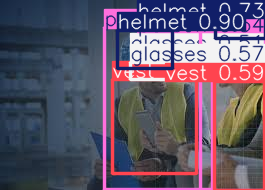


📦 Objetos detectados: 8


In [9]:
# Predicción en una imagen individual de test
import os
from IPython.display import Image, display

test_images_dir = "/content/ppe-factory-2/test/images"

# Tomar la primera imagen disponible
test_images = [f for f in os.listdir(test_images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if test_images:
    sample_image = os.path.join(test_images_dir, test_images[3])
    print(f"🖼️ Probando con: {test_images[0]}")

    results = model.predict(sample_image, save=True, imgsz=640, conf=0.25)

    # Mostrar imagen con predicciones
    results[0].show()
    print(f"\n📦 Objetos detectados: {len(results[0].boxes)}")
else:
    print("⚠️ No se encontraron imágenes en /content/ppe-factory-2/test/images/")

## 10. Predicción en todas las imágenes de test
Se itera sobre todas las imágenes del conjunto de test, ejecutando inferencia en cada una y reportando el número de detecciones.

In [10]:
# Predicción en TODAS las imágenes de test
import os
from ultralytics import YOLO

test_images_dir = "/content/ppe-factory-2/test/images"
all_images = [f for f in os.listdir(test_images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"🔍 Procesando {len(all_images)} imágenes de test...")
print("-" * 50)

for i, filename in enumerate(all_images):
    image_path = os.path.join(test_images_dir, filename)
    results = model.predict(image_path, save=True, imgsz=640, conf=0.25, verbose=False)
    n_detections = len(results[0].boxes)
    print(f"[{i+1:03d}/{len(all_images)}] {filename:<50} → {n_detections} detecciones")

print("-" * 50)
print("✅ Predicciones completadas. Resultados guardados en /content/runs/")

🔍 Procesando 143 imágenes de test...
--------------------------------------------------
Results saved to /content/runs/detect/predict
[001/143] gozluk_081_jpg.rf.7bdd6ead0276c42af2483c3616b6b219.jpg → 2 detecciones
Results saved to /content/runs/detect/predict
[002/143] images-2022-07-04T013435_jpg.rf.568e5a8cf42eb5719a8e13c79d75d934.jpg → 3 detecciones
Results saved to /content/runs/detect/predict
[003/143] images174_jpg.rf.152e2fb1fccad785bb13b232aad0189e.jpg → 1 detecciones
Results saved to /content/runs/detect/predict
[004/143] images236_jpg.rf.63077ecc6b767002a37dd10463b3ff69.jpg → 8 detecciones
Results saved to /content/runs/detect/predict
[005/143] istockphoto-1299734004-1024x1024_jpg.rf.38a11842e530ace5117f14d5546a43f9.jpg → 13 detecciones
Results saved to /content/runs/detect/predict
[006/143] outputFile2_10_png.rf.fa21841904735957ed1075feb34db88a.jpg → 10 detecciones
Results saved to /content/runs/detect/predict
[007/143] Video3_37_jpg.rf.f04bbdb4c7eea189d13d46cba98a4e68.jpg 

## 11. Descarga del video de ejemplo
Se descarga desde GitHub un video de ejemplo para realizar inferencia en video.

In [11]:
!wget -O /content/example_video.mp4 https://github.com/adiacla/ppe/raw/main/video/example_video.mp4

--2026-04-24 02:18:49--  https://github.com/adiacla/ppe/raw/main/video/example_video.mp4
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/adiacla/ppe/main/video/example_video.mp4 [following]
--2026-04-24 02:18:49--  https://raw.githubusercontent.com/adiacla/ppe/main/video/example_video.mp4
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 32903392 (31M) [application/octet-stream]
Saving to: ‘/content/example_video.mp4’

/content/example_vi 100%[===================>]  31.38M  --.-KB/s    in 0.06s   

2026-04-24 02:18:52 (559 MB/s) - ‘/content/example_video.mp4’ saved [32903392/32903392]



## 12. Predicción en video
Se ejecuta el modelo sobre el video descargado. El resultado se guarda en `/content/runs/video_test/` y se convierte a formato `.mp4` con `ffmpeg`.

In [12]:
# Predicción en un video
# Reemplazar la ruta con la de tu video descargado.
# Puedes descargarlo y subirlo a /content/ o a Google Drive.

video_source = "/content/example_video.mp4"  # <--- ¡IMPORTANTE! Esta es la ruta del video descargado de GitHub

# Asegúrate de que el modelo esté cargado. Si no has ejecutado las celdas anteriores,
# podrías necesitar ejecutar: model = YOLO("/content/runs/ppe_detector/weights/best.pt")

if os.path.exists(video_source):
    results = model.predict(
        source=video_source,
        conf=0.3,
        save=True,
        project="/content/runs",
        name="video_test"
    )
    print("✅ Predicción en video completada. Resultados guardados en /content/runs/video_test/")
else:
    print(f"⚠️ No se encontró el video en: {video_source}")
    print("Asegúrese de haber descargado el video y que la ruta sea correcta.")

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /content/runs/video_test
✅ Predicción en video completada. Resultados guardados en /content/runs/video_test/


## 13. Exportación del modelo a ONNX
Se exporta el modelo entrenado al formato ONNX (opset 12), compatible con múltiples frameworks de inferencia y plataformas de despliegue.

In [13]:
!ffmpeg -i /content/runs/video_test/example_video.avi /content/runs/video_test/example_video.avi.mp4


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

## 14. Descarga de los archivos del modelo
Se descargan los archivos `best.pt` (PyTorch) y `best.onnx` (ONNX) desde el entorno de Colab al equipo local.

In [14]:
# Exportar a ONNX (recomendado para interoperabilidad)
print("⏳ Exportando a ONNX...")
model.export(format="onnx", opset=12)
print("✅ Exportado a ONNX")

⏳ Exportando a ONNX...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/ppe_detector/weights/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 11, 3549) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 201ms
Prepared 4 packages in 6.70s
Installed 4 packages in 321ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.25.0
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 7.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 9.2s, 

In [15]:
from google.colab import files
import os

# Define the paths to the model files
best_pt_path = "/content/runs/ppe_detector/weights/best.pt"
best_onnx_path = "/content/runs/ppe_detector/weights/best.onnx"

print("Downloading best.pt...")
if os.path.exists(best_pt_path):
    files.download(best_pt_path)
else:
    print(f"⚠️ best.pt not found at {best_pt_path}")

print("Downloading best.onnx...")
if os.path.exists(best_onnx_path):
    files.download(best_onnx_path)
else:
    print(f"⚠️ best.onnx not found at {best_onnx_path}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>